# Исследование структуры финансирования стартапов

Автор: Даулетжан Баймуханов

Дата: 20.02.2026

## Введение

### Цель и задачи проекта

Цель: Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.

Задачи:
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

### Структура проекта

1. [Знакомство с данными](#chapter_one)
2. [Инжиниринг признаков](#chapter_two)
3. [Работа с выбросами и анализ](#chapter_three)
4. [Анализ динамики](#chapter_four)
5. [Выводы и рекомендации](#chapter_five)

<a id='chapter_one'></a>
## Знакомство с данными

Для исследования были взяты два датасета из платформы бизнес-аналитики CB Insights на начало 2015 года. Первый (основной) датасет — `cb_investments.csv`, хранится в архивированной папке – `cb_investments.zip` и содержит всю необходимую информацию для исследования. Второй (вспомогательный) датасет — `cb_returns.csv`, содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных основного датасета (`cb_investments.csv`):
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Описание данных дополнительного датасета (`cb_returns.csv`):
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Загрузка библиотек и данных

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменные df и df_returns
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)
df_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

### Знакомство с данными датасета `cb_investments.csv`

In [3]:
# Устанавливаем максимальное количество отображаемых столбцов
pd.set_option('display.max_columns', None)

In [4]:
# Выводим первые строки датафрейма на экран
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


На первый взгляд, данные содержащиеся в датасете соответствуют описанию.

In [5]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

В датасете имеется множество пропусков.

In [6]:
# Считаем долю пропусков в столбцах в процентах
df.isna().mean() * 100

name                     8.945740
homepage_url            15.296350
category_list           16.239363
 market                 16.239363
 funding_total_usd       8.943898
status                  11.364055
country_code            18.655837
state_code              44.448742
region                  18.655837
city                    20.208494
funding_rounds           8.943898
participants            43.874093
founded_at              28.990312
founded_month           29.122923
founded_quarter         29.122923
founded_year            28.990312
first_funding_at         8.943898
mid_funding_at          44.214830
last_funding_at          8.943898
seed                     8.943898
venture                  8.943898
equity_crowdfunding      8.943898
undisclosed              8.943898
convertible_note         8.943898
debt_financing           8.943898
angel                    8.943898
grant                    8.943898
private_equity           8.943898
post_ipo_equity          8.943898
post_ipo_debt 

#### Промежуточные выводы:

Основной датасет `cb_investments.csv` содержит 40 столбцов и 54294 строк. Данные содержащиеся в датасете соответствуют описанию и дают информацию финансировании стартапов.

После первичного анализа данных можно сделать следующие выводы:
- В названиях некоторых столбцов присутствуют пробелы, что усложняет работу с ними, их нужно обрабатывать.
- Во всех столбцах имеются пропуски. В большинстве столбцов около 9 % строк имеют пропуски. Возмоожное истинное количество строк равно – 49438. Это самое большое и часто встречающееся количество заполненных строк. Самое большое количество пропусков в столбцах `mid_funding_at` и `state_code`, где этот показатель превышает 44 %. Пропуски в `state_code` можно легко объяснить тем, что не все стартапы из США. Также в столбце `participants` имеется около 44 % пропусков.
- В столбце `funding_total_usd` используется не верный тип данных, вместо `float64` используется `object`.
- В столбцах `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at` используется не верный тип данных, вместо `datetime64` используется `object`.
- Для удобства можно поменять тип в столбцах, хранящих категориальные данные, таких как `market`, `status`, `country_code`, `state_code`, и `city` с `object` на `category`.
- В датасете можно оптимизировать данные в столбцах, которые хранят числовые данные, уменьшив их битовый разряд. Например, в следующих столбцах - `funding_rounds` и `participants`.


### Знакомство с данными датасета `cb_returns.csv`

In [7]:
# Выводим первые строки датафрейма на экран
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [8]:
# Выводим информацию о датафрейме
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


#### Промежуточные выводы:

Датасет `cb_returns.csv` содержит 14 столбцов и 15 строк. Данные содержащиеся в датасете соответствуют описанию и дают информацию об общем финансировании стартапов по годам.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов представлены корректно, их не нужно обрабатывать.
- В столбцах нет пропусков.
- Все столбцы содержат числовые данные.
- Можно оптимизировать данные во всех столбцах уменьшив их битовый разряд так как в них хранятся не столь большие величины.

### Предобработка данных

In [9]:
# Выводим названия столбцов в датафрейме df
df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

В названиях столбцов имеются пробелы.

In [10]:
# Удаляем пробелы из названия столбцов
df.columns = df.columns.str.strip()

Проверяем корректность изменения названий столбцов.

In [11]:
# Выводим названия столбцов в датафрейме df
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

Названия столбцов изменены корректно.

In [12]:
# Выводим названия столбцов в датафрейме df_returns
df_returns.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

В датафрейме `df_returns` названия столбцов корректны.

In [13]:
# Знакомимся с содержанием столбца funding_total_usd
df['funding_total_usd'].head()

0     9,00,00,000 
1       20,00,000 
2       90,00,000 
3       77,00,000 
4        5,40,000 
Name: funding_total_usd, dtype: object

In [14]:
# Убираем в столбце funding_total_usd выделение разрядов и приведим его к числовому типу
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'].str.replace(',', '', regex=False), errors='coerce')

In [15]:
# Проверяем корректность изменения типа данных
print(f"Тип данных в столбце funding_total_usd: {df['funding_total_usd'].dtypes}")

Тип данных в столбце funding_total_usd: float64


In [16]:
# Выводим первые строки столбца на экран
df['funding_total_usd'].head()

0    90000000.0
1     2000000.0
2     9000000.0
3     7700000.0
4      540000.0
Name: funding_total_usd, dtype: float64

Столбец `funding_total_usd` приведен к числовому типу.

Для дальнейшей проверки корректности изменений посчитаем количество значений в столбцах, хранящих значения даты и времени.

In [17]:
# Создаем список с названиями столбцов, хранящих значения даты и времени
date_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
# Создаем пустой словарь
temp_dict = {}

# Считаем изначальное количество значений в столбцах
for col in date_columns:
    temp_dict[col] = df[col].count()

# Сохраняем результат в серии
date_initial_val_count = pd.Series(temp_dict)

Исправляем неверный тип данных в столбцах `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at` с `object` на `datetime64`.

In [18]:
# Меняем тип данных в столбцах, хранящих значения даты и времени
for col in date_columns:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d', errors = 'coerce')

In [19]:
# Проверяем корректность изменения типа данных
for col in date_columns:
    print(f"В столбце {col} хранится тип данных: {df[col].dtype}")

В столбце founded_at хранится тип данных: datetime64[ns]
В столбце first_funding_at хранится тип данных: datetime64[ns]
В столбце mid_funding_at хранится тип данных: datetime64[ns]
В столбце last_funding_at хранится тип данных: datetime64[ns]


Тип данных изменен корректно.

In [20]:
# Проверяем корректность написания даты
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,1.0,NaN,NaT,NaN,NaN,1636.0,2014-01-06,NaT,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaT,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaT,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Написание даты корректно.

In [21]:
# Обнуляем словарь
temp_dict = {}

# Считаем итоговое количество значений в столбцах
for col in date_columns:
    temp_dict[col] = df[col].count()

# Сохраняем результат в серии
date_final_val_count = pd.Series(temp_dict)

In [22]:
# Считаем долю сохранившихся значений после предобработки столбцов, хранящих значения даты и времени
date_final_val_count.div(date_initial_val_count, axis=0)

founded_at          0.999974
first_funding_at    0.999798
mid_funding_at      1.000000
last_funding_at     0.999879
dtype: float64

В результате предобработки в столбцах `founded_at`, `first_funding_at`, и `last_funding_at` было удалено незначительное количество значений – менее 1 %.

In [23]:
# Проверяем текущие индексы
df_returns.index

RangeIndex(start=0, stop=15, step=1)

В датафрейме установлены индексы по умолчанию.

In [24]:
# Делаем столбец year индексом всего датасета
df_returns = df_returns.set_index('year')

In [25]:
# Снова проверяем индексы
df_returns.index

Int64Index([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
            2011, 2012, 2013, 2014],
           dtype='int64', name='year')

In [26]:
# Выводим первые строки датафрейма на экран
df_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Индексы изменились корректно.

На первый взгляд обработка текстовых данных не выглядит необходимой, но учитывая большое количество данных (строк) в датасете стоит провести нормализацию данных в столбцах `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code` и `region, city` перед обработкой дубликатов.

In [27]:
# Создаем список с названиями столбцов, хранящих текстовые данные
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']

# Проводим нормализацию данных в столбцах, хранящих текстовые данные
for col in text_columns:
    df[col] = df[col].str.lower().str.strip()
    
# Проверяем корректность изменения
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,1.0,NaN,NaT,NaN,NaN,1636.0,2014-01-06,NaT,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaT,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaT,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Текстовые данные успешно нормализованы.

В данных имеются строки с пропущенным именем (`name`) стартапа. Возможно, в этих строках заполнены ссылка на электронный адрес (`homepage_url`), которые можно использовать, как заглушку для названия.

In [28]:
# Выводим на экран строку с пропущенным названием и наличием ссылки
df[df['name'].isna() & df['homepage_url'].notna()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
27212,NaN,http://tellitin10.com,|startups|,startups,25000.0,closed,NaN,NaN,NaN,NaN,1.0,NaN,2011-10-01,2011-10,2011-Q4,2011.0,2012-03-01,NaT,2012-03-01,25000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Такая строка только одна.

In [29]:
# Сохраняем строку с пропуском в имени
missing_name_row = df[df['name'].isna() & df['homepage_url'].notna()]

# Извлекаем электронный адрес из этой строки
homepage_url = missing_name_row['homepage_url'].values[0]

# Извлекаем название организации из электронного адреса
start_index = homepage_url.find("http://") + len("http://")
end_index = homepage_url.find(".com")
company_name = homepage_url[start_index:end_index]

# Заполняем пропуск в столбце name
df.loc[missing_name_row.index, 'name'] = company_name

# Проверяем корректность заполнения
df.loc[missing_name_row.index, 'name']

27212    tellitin10
Name: name, dtype: object

Пропуск успешно заполнен заглушкой.

In [30]:
# Проверяем наличие полных дубликатов в основном датафрейме
print('Количество полных дубликатов в основном датафрейме:')
df.duplicated().sum()

Количество полных дубликатов в основном датафрейме:


4855

В датафрейме `df` имеется 4855 полных дубликатов.

In [31]:
# Знакомимся с полными дубликатами
df[df.duplicated()]

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
49439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Полными дубликатами являются строки с пропусками во всех столбцах.

In [32]:
# Удаляем полные дубликаты
df = df.drop_duplicates(keep=False)

In [33]:
# Проверяем удаление полных дубликатов
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 49438 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49438 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  object        
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Все строки с пропусками во всех столбцах удалены.

Переходим к обработке пропусков в столбце `funding_total_usd`.

In [34]:
# Считаем количество пропусков в столбце funding_total_usd.
print('Количество пропусков в столбце funding_total_usd до обработки:')
df['funding_total_usd'].isna().sum()

Количество пропусков в столбце funding_total_usd до обработки:


8531

В столбце `funding_total_usd` встречается 8531 пропуск.

In [35]:
# Удаляем строки в которых есть пропуски в funding_total_usd
df = df.dropna(subset=['funding_total_usd'])

In [36]:
# Считаем количество пропусков в столбце funding_total_usd.
print('Количество пропусков в столбце funding_total_usd после обработки:')
df['funding_total_usd'].isna().sum()

Количество пропусков в столбце funding_total_usd после обработки:


0

Пропуски в столбце `funding_total_usd` успешно обработаны.

In [37]:
# Считаем количество пропусков в столбце mid_funding_at
print('Количество пропусков в столбце mid_funding_at:')
df['mid_funding_at'].isna().sum()

Количество пропусков в столбце mid_funding_at:


13676

Количество пропусков в столбце `mid_funding_at`: 13676.

In [38]:
# Проверяем наличие столбцов с одинаковыми датами first_funding и last_funding_at
df[df['first_funding_at'] == df['last_funding_at']]['name'].count()

24289

Если имеется только одно финансирование, то оно считается и первым и последним финансированием. Это облегчает задачу, не нужно прописовать дополнительный код (`if-else`).

In [39]:
# Проверяем наличие столбцов, где first_funding больше last_funding_at
df[df['first_funding_at'] > df['last_funding_at']]['name'].count()

0

In [40]:
# Проверяем наличие столбцов, где mid_funding_at меньше first_funding
df[df['first_funding_at'] > df['mid_funding_at']]['name'].count()

546

In [41]:
# Проверяем наличие столбцов, где mid_funding_at больше last_funding_at
df[df['last_funding_at'] < df['mid_funding_at']]['name'].count()

111

В столбце `mid_funding_at` имеются не корректные данные. Например, встречаются 546 случая, когда первое финансирование произошло позже среднего. Также, встречаются 111 случая, когда среднее финансирование произошло позже последнего финансирования.

In [42]:
# Считаем средний интервал между датой первого и последнего финансирования
calculated_mid_funding = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2 

# Заполняем пропуски
df['mid_funding_at'] = df['mid_funding_at'].fillna(calculated_mid_funding)

# Проверяем корректность заполнения
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                38404 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

In [43]:
# Проверяем наличие столбцов, где mid_funding_at меньше first_funding
df[df['first_funding_at'] > df['mid_funding_at']]['name'].count()

546

In [44]:
# Проверяем наличие столбцов, где mid_funding_at больше last_funding_at
df[df['last_funding_at'] < df['mid_funding_at']]['name'].count()

111

Пропуски в значениях `mid_funding_at` заполнены корректно. Количество аномальных значений не увеличилось.

In [45]:
# Оцениваем размер оставшихся пропусков в столбце
df['mid_funding_at'].isna().sum()

1

После предобработки осталось всего 1 строка с пропуском. Это незначительное количество, которое можно оставить, как есть.

#### Промежуточные выводы:

В результате предобработки данных были выполнены следующие действия:
- Названия столбцов в датафрейме `df` приведены к одной форме. Удалены пробелы в названиях.
- Столбец `funding_total_usd` приведен к числовому типу.
- Исправлен неверный тип данных в столбцах `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at` с `object` на `datetime64`. В результате предобработки в столбцах `founded_at`, `first_funding_at`, и `last_funding_at` было удалено незначительное количество значений – менее 1 %.
- В датасете `cb_returns` столбец `year` сделан индексом всего датасета.
- Столбцы – `name`, `homepage_url`, `category_list`, `market`, `status`, `country_code`, `state_code` и `region`, `city` – хранящиие текстовые данные успешно нормализованы.
- Заполнены пропуски в столбце name данными из столба `homepage_url`. Заполнено название только одной строки.
- Удалены 4855 полных дубликатов, включая «оригинал» (+1), так как они содержали только пустые значения во всех ячейках. Было удалено около 9 % строк. В обновлённом датафрейме храниться 49438 строк.
- Обработан 8531 пропуск в столбце `funding_total_usd` путем удаления.
- Заполнены 13675 из 13676 пропусков в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В оставшихся 8 пропусках не данных в столбце `first_funding_at`.
- Большая часть оставшихся пропусков относятся к столбцам, которые не важны для данного исследования, и их можно отбросить (удалить) или просто проигнорировать. Следующие столбцы не важны для данного исследования: `homepage_url`, `category_list`, `status`, `country_code`, `state_code`, `region`, `city`, `founded_at`, `founded_month`, `founded_quarter`, и `founded_year`.

После предобработки имеется достаточное количество данных для решения задач проекта. После предобработки было отброшено около 15% строк. Они были полными дубликатами и содержали пустые значения во всех строках или содержали пропуски в столбце `funding_total_usd`.

<a id='chapter_two'></a>
## Инжиниринг признаков

### Разделяем все стартапы на три группы по срокам финансирования

In [46]:
# Создаем новый столбец, хранящий категориальное значение по срокам финансирования, и присваиваем ему значение по умолчанию
df['funding_type'] = 'более года'

# Меняем значение по умолчанию для единичных финансирований
df.loc[df['funding_rounds'] == 1, 'funding_type'] = 'единичное'
# Меняем значение по умолчанию для финансирований сроком до года
df.loc[(df['funding_rounds'] > 1) & ((df['last_funding_at'] - df['first_funding_at']) < '365 days'), 'funding_type'] = 'до года'

In [47]:
# Проверяем успешное создание нового столбца
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40907 entries, 0 to 49437
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40907 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                38404 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founded_at            32200 non-null  datetime64[ns]
 13  founded_month   

Столбец `funding_type` успешно создан и содержит 40907 значений.

Переходим к подсчету количества компаний, относящихся к каждой из трёх групп.

In [48]:
# Считаем количество компаний относящихся к каждой из трёх групп и сохраняем в переменную
grouped_data_cnt = df.groupby('funding_type')['name'].count()
# Выводим на экран
print(grouped_data_cnt)

funding_type
более года    12387
до года        4407
единичное     24113
Name: name, dtype: int64


Переходим к подсчету объёма привлечённых средств каждой группой финансирования.

In [49]:
# Считаем объём привлечённых средств каждой группой финансирования
grouped_data_sum = df.groupby('funding_type')['funding_total_usd'].sum()
# Выводим на экран
print(grouped_data_sum)

funding_type
более года    4.037737e+11
до года       4.785555e+10
единичное     1.993044e+11
Name: funding_total_usd, dtype: float64


Визуализируем для наглядности.

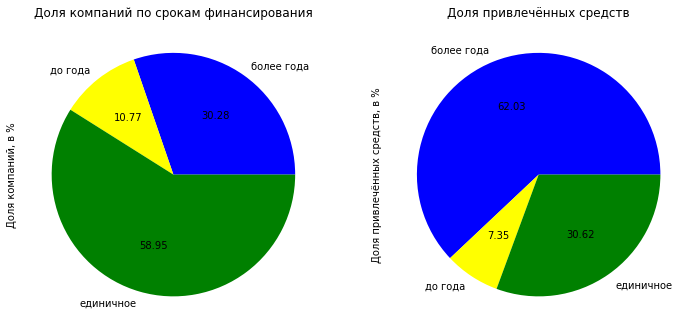

In [50]:
# Создаем словарь, хранящий цветовую палитру для категорий финансирования
color_dict = {'единичное': 'green', 'до года': 'yellow', 'более года': 'blue'}

# Упорядочиваем список цветов
color_list_cnt = [color_dict[category] for category in grouped_data_cnt.index]
color_list_sum = [color_dict[category] for category in grouped_data_sum.index]

# Создаём контейнер для подграфиков matplotlib и задаём его размер
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Строим круговую диаграмму для grouped_data_cnt на первой оси
axes[0].pie(grouped_data_cnt, labels=grouped_data_cnt.index, colors=color_list_cnt, autopct='%.2f')
# Настраиваем оформление графика
axes[0].set_ylabel('Доля компаний, в %')
axes[0].set_title('Доля компаний по срокам финансирования')

# Строим круговую диаграмму для grouped_data_sum на второй оси
axes[1].pie(grouped_data_sum, labels=grouped_data_sum.index, colors=color_list_sum, autopct='%.2f')
# Настраиваем оформление графика
axes[1].set_ylabel('Доля привлечённых средств, в %')
axes[1].set_title('Доля привлечённых средств')

# Выводим график
plt.show()

Компании со сроком финансирования `более года` привлекли 62% всех инвестиций при том, что только 30% компаний относятся к этой группе. А группа, к которой относится около 60% компаний – `единичное`, привлекла менее трети инвестиций (30,6%). Неменьшее количество инвестиций, привлекла группа `до года` – 7,35%, что не удивительно – она самая маленькая группа по количеству компаний (10,77%).

### Выделяем сегменты рынка

In [51]:
# Считаем общее количество сегментов рынка
print(f"Общее количество сегментов: {df['market'].nunique()}.")

Общее количество сегментов: 394.


Общее количество сегментов рынка, представленных в датасете – 394.

In [52]:
# Считаем, как часто в датасете встречается каждый из сегментов
segment_counts = df.groupby('market')['name'].count().sort_values(ascending=False)
# Выводим на экран
print(segment_counts)

market
software                 4812
biotechnology            3590
mobile                   2344
e-commerce               1866
curated web              1693
                         ... 
fleet management            1
professional services       1
project management          1
flash storage               1
women                       1
Name: name, Length: 394, dtype: int64


Самыми популярными сегментами являются `software` и `biotechnology` на них приходятся 4812 и 3590 компания. Однако, в датасете также встречаются сегменты с единичным случаем представительства.

Категоризируем сегменты на `массовый`, `средний`, и `нишевой`.

In [53]:
# Определяем функцию для классификации сегментов
def classify_segment(count):
    if count > 120:
        return 'массовый'
    elif 35 <= count <= 120:
        return 'средний'
    else:
        return 'нишевой'

# Применяем функцию к каждому сегменту и создаем новый DataFrame
segment_groups = segment_counts.reset_index(name='count')
segment_groups['group'] = segment_groups['count'].apply(classify_segment)

In [54]:
# Рассчитываем сколько сегментов попадает в каждую из категорий
segment_groups.groupby('group')['market'].count().sort_values(ascending=False)

group
нишевой     289
средний      57
массовый     48
Name: market, dtype: int64

Визуализируем для наглядности.

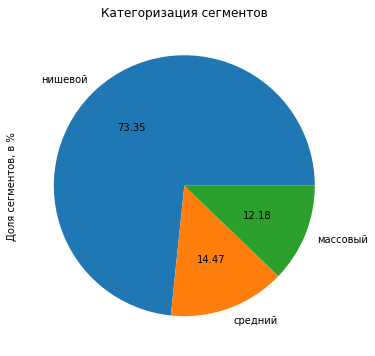

In [55]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим круговую диаграмму с помощью pandas через plot(kind='pie')
segment_groups.groupby('group')['market'].count().sort_values(ascending=False).plot(
                kind='pie', 
                rot=0,
                legend=False,
                autopct='%.2f', 
                title='Категоризация сегментов'
)

# Настраиваем оформление графика
plt.ylabel('Доля сегментов, в %')

# Выводим график
plt.show()

Львиная доля (73.35%) сегментов, представленных в датасете относятся к `нишевым` сегментам. В  `среднем` и `массовом` сегментах представлены соизмеримые количества сегментов – 57 и 48 соответственно.

Визуализируем распределение компаний в нишевом и среднем сегментах.

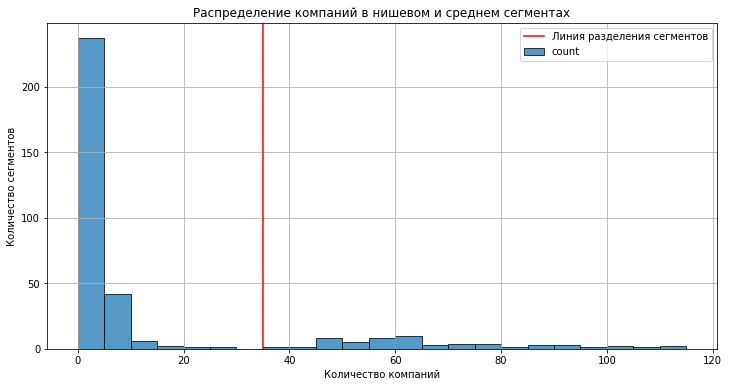

In [56]:
# Строим гистограмму с помощью pandas через plot(kind='hist')
segment_groups.plot(
                kind='hist',
                figsize=(12, 6),
                bins=range(0,120,5),
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Добавляем линию разделения сегментов
plt.axvline(35, color='red', label='Линия разделения сегментов')
# Выводим легенду на график
plt.legend()

# Настраиваем оформление графика
plt.title('Распределение компаний в нишевом и среднем сегментах')
plt.xlabel('Количество компаний')
plt.ylabel('Количество сегментов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Данные количества компаний в сегментах имеют ненормальное (ассиметричное) распределение. Имеет место правосторонняя скошенность. Более 250 сегментов (это более 50% сегментов) имеют от 1 до 5 компаний и относятся к `нишевому` сегменту. Наиболее часто встречающееся количество компании в `средних` сегментах – 65.

Для удобства исследования в столбце `market` оставим только `массовые` сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [57]:
# Создаём словарь для сопоставления сегментов с группами
segment_to_group = segment_groups.set_index('market')['group'].to_dict()

# Создаём функцию для замены значений
def replace_market_values(segment):
    if segment_to_group.get(segment) == 'массовый':
        return segment
    elif segment_to_group.get(segment) == 'средний':
        return 'mid'
    elif segment_to_group.get(segment) == 'нишевой':
        return 'niche'
    else:
        return None

# Применяем функцию к каждой строке в столбце market датафрейма df
df['market'] = df['market'].apply(replace_market_values)

# Выводим результат
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,funding_type
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,1.0,NaN,NaT,NaN,NaN,1636.0,2014-01-06,2014-01-06,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное
1,university of new brunswick,http://www.unb.ca,NaN,None,2000000.0,operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,2014-05-15,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,mid,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,до года
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,2014-01-14,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное


В столбце `market` остались только массовые сегменты. Для остальных сегментов значения заменены на заглушки — `niche` для нишевых и `mid` для средних.

Проведем дополнительную аналитику.

In [58]:
# Посчитаем количество компаний в каждом сегменте
segment_groups.groupby('group')['count'].sum().sort_values(ascending=False)

group
массовый    33733
средний      3841
нишевой       830
Name: count, dtype: int64

Визуализируем для наглядности.

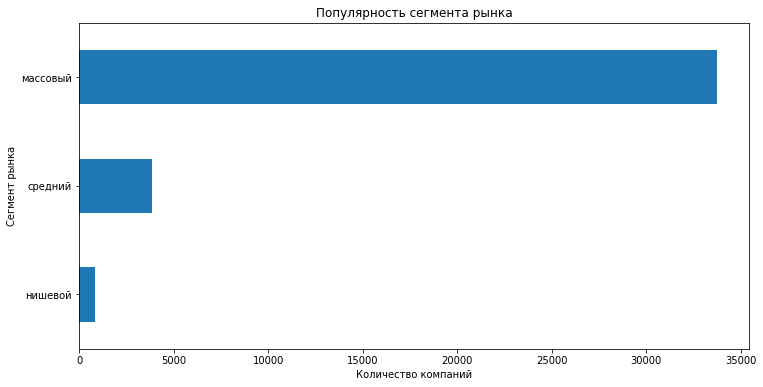

In [59]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
segment_groups.groupby('group')['count'].sum().sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Популярность сегмента рынка'
)

# Настраиваем оформление графика
plt.xlabel('Количество компаний')
plt.ylabel('Сегмент рынка')

# Выводим график
plt.show()

Несмотря на значительно большое количество сегментов в `нишевой` группе, ее популярность крайне низка. В `массовом` сегменте занято 33 733 компаний или почти 88% всех сегментированных компаний.

Выведем самые популярные сегменты.

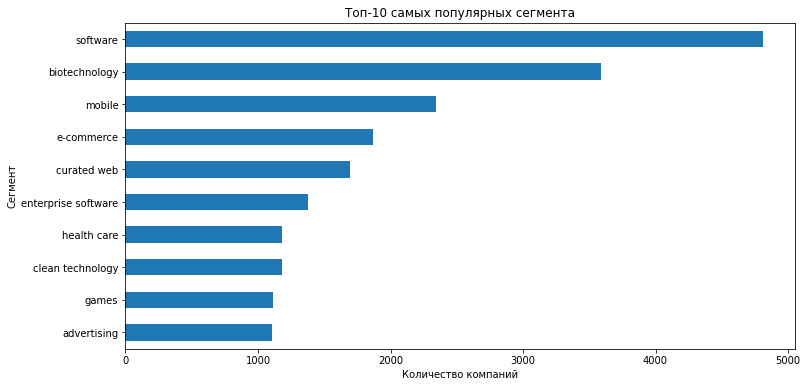

In [60]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
segment_counts.head(10).sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Топ-10 самых популярных сегмента'
)

# Настраиваем оформление графика
plt.xlabel('Количество компаний')
plt.ylabel('Сегмент')

# Выводим график
plt.show()

Самыми популярными сегментами являются `software` и `biotechnology`.

### Промежуточные выводы:

- Только 30% компаний, получивших финансирование продолжают быть интересными для инвесторов через год (`более года`) после первого раунда инвестиций. А около 60% компаний, получают финансирование единожды. Поэтому при вложении денег в технологическую компанию, стоит иметь ввиду, что только 30% компаний даже после получения инвестиций переживают первый год.
- В датасете представлено внушительное количество сегментов рынка – 394, что указывает на высокую гранулированность (детализированность) данных. Львиная доля (73.35%) сегментов относятся к нишевой группе, что указывает на наличие небольшого количества сегментов «чемпионов», которые сопровождаются длинным «хвостом» из все более узких проблемных сегментов. Узость сегмента может быть связана с зарождающейся отраслью, лимитированным размером рынка, отсутствием регулирования или другими факторами, которые делают сегмент менее интересным для инвесторов. Здесь стоит напомнить, что мы рассматриваем, только компании, которые получили инвестирование.
- Сегментов «чемпионов», или `массовых` (популярных) сегментов, которые привлекают большое количество компаний, в датасете – 48. В них занято 33 733 компаний или почти 88% всех сегментированных компаний. В пятерку самых популярных сегментов входят – `программное обеспечение`, `биотехнологии`, `мобильные разработки`, `электронная коммерция` и `курируемые платформы`.


Таким образом, рынок стартапов, отличается высокой избирательностью и высокой степенью риска. Даже после привлечения инвестиций лишь около 30% компаний остаются жизнеспособными через год после первого раунда финансирования, а примерно 60% получают финансирование только один раз, что указывает на то, что первоначальные инвестиции функционируют скорее как фильтрующий механизм, чем как гарантия выживания. Хотя рынок выглядит разнообразным, насчитывая 394 выявленных сегмента, это разнообразие в значительной степени поверхностно: более 73% сегментов являются нишевыми, образуя длинный «хвост» узкоспециализированных направлений. Всего 48 «ведущих» сегментов концентрируют почти 88% всех сегментированных компаний (33 733 фирмы). В подавляющем большинстве стартапы сосредоточены на проверенных областях, таких как `программное обеспечение`, `биотехнологии`, `мобильные технологии`, `электронная коммерция` и `курируемые платформы`. В целом, рынок напоминает крутую пирамиду — широкие эксперименты в основании, но выживание и масштабирование сосредоточены в небольшом количестве знакомых, предпочитаемых инвесторами сегментах.

<a id='chapter_three'></a>
## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

In [61]:
# Изучаем статистические показатели столбца funding_total_usd
print('Статистические показатели столбца funding_total_usd:')
df['funding_total_usd'].describe()

Статистические показатели столбца funding_total_usd:


count    4.090700e+04
mean     1.591253e+07
std      1.686788e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

Данные о средствах, предоставленных компаниям, имеют ненормальное (ассиметричное) распределение. Имеет место правосторонняя скошенность.

In [62]:
# Рассчитываем межквартильный размах IQR
iqr = df['funding_total_usd'].quantile(0.75) - df['funding_total_usd'].quantile(0.25)
# Вычисляем нижний порог для выбросов
lower_threshold = df['funding_total_usd'].min()
# Вычисляем верхний порог для выбросов
upper_threshold = df['funding_total_usd'].quantile(0.75) + 1.5 * iqr
# Выводим на экран верхний порог для выбросов
print(f'Типичный размер общего финансирования для одной компании равен от {lower_threshold} до {upper_threshold}.')

Типичный размер общего финансирования для одной компании равен от 1.0 до 24475000.0.


Визуализируем типичные показатели для наглядности.

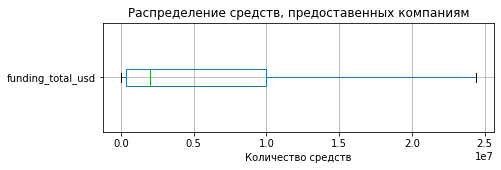

In [63]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='funding_total_usd', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение средств, предоставенных компаниям')
plt.xlabel('Количество средств')

# Выводим график
plt.show()

Типичный размер общего финансирования для одной компании равен от 1.0 до 24475000.0.

Определяем компании с аномальным объёмом общего финансирования по каждому сегменту.

In [64]:
# Выписываем уникальные названия сегментов
markets = df['market'].unique()
# Создаем столбец, отвечающий на вопрос аномальное выражение или нет 
df['outlier'] = False

# Определяем компании с аномальным объёмом общего финансирования по каждому сегменту
for market_type in markets:
    maket_type_data = df[df['market'] == market_type]
    q1 = maket_type_data['funding_total_usd'].quantile(0.25)
    q3 = maket_type_data['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - 1.5 * iqr
    upper_threshold = q3 + 1.5 * iqr
    df.loc[((df['funding_total_usd']  > upper_threshold) | (df['funding_total_usd']  < lower_threshold)) & (df['market'] == market_type), 'outlier'] = True

In [65]:
# Подсчитываем общее количество компаний в каждом сегменте
total_companies_per_market = df[df['market'] != 'unknown'].groupby('market').size()

# Подсчитываем количество аномальных случаев в каждом сегменте
anomalous_cases_per_market = df[df['market'] != 'unknown'].groupby('market')['outlier'].sum()

# Вычисляем долю аномальных случаев в %
market_share_anomalies = round(anomalous_cases_per_market / total_companies_per_market * 100, 2)

# Сортируем результаты по убыванию доли
sorted_market_share_anomalies = market_share_anomalies.sort_values(ascending=False)

# Выводим топ-10 сегментов
print(sorted_market_share_anomalies.head(10))

market
real estate        17.20
entertainment      16.67
consulting         16.62
search             16.49
cloud computing    16.45
saas               16.18
photography        16.18
technology         15.97
video              15.96
niche              15.90
dtype: float64


Визуализируем результат для наглядности.

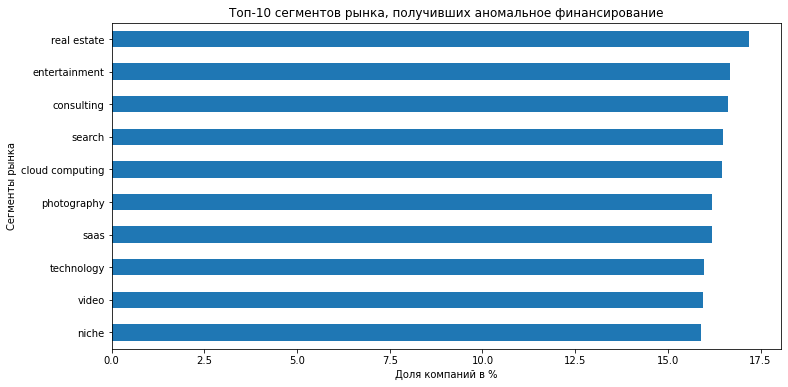

In [66]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
sorted_market_share_anomalies.head(10).sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Топ-10 сегментов рынка, получивших аномальное финансирование'
)

# Настраиваем оформление графика
plt.xlabel('Доля компаний в %')
plt.ylabel('Сегменты рынка')

# Выводим график
plt.show()

Сегментом рынка с наибольшей долей компаний, получивших аномальное финансирование, является `transportation`. В нем около 19 % компаний получили средства выше типичных значений по сегменту. На втором месте медицинские устройства (`medical devices`) с чуть более 18% аномальных значений. В топ-3 также входит сегмент `travel` с 17,43% аномалий. Стоит отметить, что в топ-10 вошел и самый «разношерстный» сегмент – `niche` с 16,23%.

Сегментом рынка с наибольшей долей компаний, получивших аномальное финансирование, является недвижимость (`real estate`). В нем около 17,2 % компаний получили средства выше типичных значений по сегменту. У остальных сегментов вошедших в топ-10 доля аномальных значений составляет +/- 16%.

### Определяем границы рассматриваемого периода, отбрасываем аномалии

In [67]:
# Ищем самую позднюю дату финансирования
df['last_funding_at'].max()

Timestamp('2014-12-31 00:00:00')

Самой поздней датой финансирования встречающейся в датасете является 31 декабря 2014 года. Можно предположить, что представлены полные данные за 2014 год. Для уверенности проверим присутствие всех месяцев 2014 года в датасете.

In [68]:
# Проверяем присутствие всех месяцев 2014 года в датасете
df[(df['last_funding_at'] > '2014-01-01') & (df['last_funding_at'] < '2015-01-01')]['last_funding_at'].dt.month.unique()

array([ 1,  5, 11, 10,  9,  2,  7,  6,  8,  3,  4, 12])

В датасете присутствуют все 12 месяцев 2014 года, можно с высокой долей уверенности предположить, что нам предоставили полные данные за 2014 год.

In [69]:
# Исключаем из датасета компании, которые мы ранее посчитали получившими аномальное финансирование
df = df[df['outlier'] == False]

In [70]:
# Исключаем из датасета компании, у которых имеются пропуски в столбце mid_funding_at
df = df[df['mid_funding_at'].notna()]

In [71]:
# Создаем столбец с годом финансирования
df['funding_year'] = df['mid_funding_at'].dt.year

In [72]:
# Создаем серию, хранящую количество раудов в год
rounds_per_year = df.groupby('funding_year')['funding_rounds'].sum()
# Выводим результат на экран
print(rounds_per_year.sort_values(ascending=False))

funding_year
2013    12945.0
2012     9753.0
2011     7617.0
2014     7244.0
2010     6199.0
2009     4669.0
2008     3686.0
2007     2849.0
2006     1881.0
2005      958.0
2004      189.0
2003      128.0
2000      122.0
2002      107.0
2001       84.0
1999       47.0
1998       15.0
1995        9.0
1996        8.0
1997        5.0
1992        5.0
1994        4.0
1985        3.0
1982        3.0
1960        2.0
1987        2.0
1984        2.0
1993        1.0
1990        1.0
1989        1.0
1983        1.0
1979        1.0
1921        1.0
Name: funding_rounds, dtype: float64


Самым активным годом по количеству раундов финансирования был 2013 год с 12945 раундами. А до 2000 года, количество раундов не превышало 50. Компании со следующими годами финансирования нужно исключить: 1999, 1998, 1996, 1995, 1997, 1993, 1994, 1992, 1990, 1991, 1987, 1985, 1984, 1989, 1986, 1960, 1982, 1988, 1974, 1983, 1979, 1973, 1921.

Визуализируем результат для наглядности.

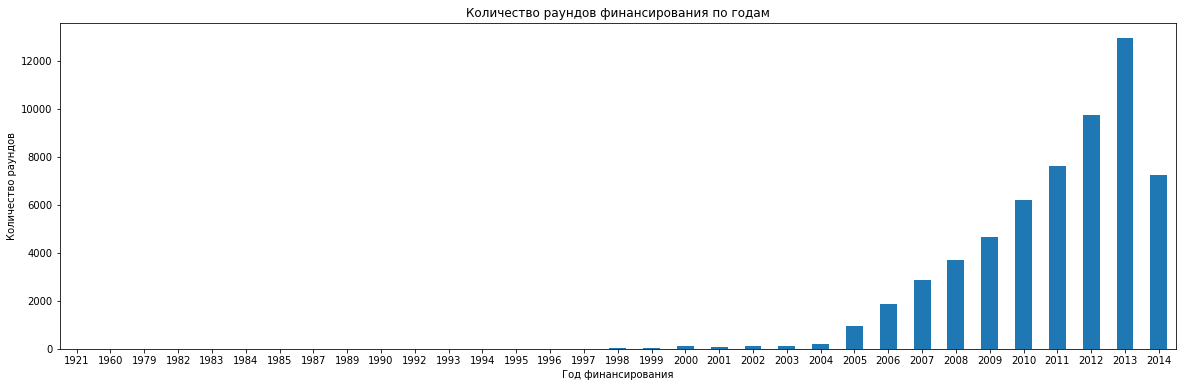

In [73]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
rounds_per_year.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Количество раундов финансирования по годам'
)

# Настраиваем оформление графика
plt.xlabel('Год финансирования')
plt.ylabel('Количество раундов')

# Выводим график
plt.show()

In [74]:
# Создаём словарь для сопоставления года финансирования с количеством раундов
rounds_per_year_dict = rounds_per_year.to_dict()
# Создаем столбец, отвечающий на вопрос финансово-активный год или нет
df['busy_year'] = False

# Создаем функцию для заполнения столбца busy_year
def busy_year_finder(year):
    if rounds_per_year_dict.get(year) >= 50:
        return True
    else:
        return False

# Применяем функцию к каждой строке в столбце funding_year
df['busy_year'] = df['funding_year'].apply(busy_year_finder)

In [75]:
# Исключаем из датасета компании, которые получили финансирование в годы, когда было зафиксировано менее 50 раундов финансирования
df = df[df['busy_year'] == True]

# Проверяем результат
df['funding_year'].unique()

array([2014, 2009, 2013, 2007, 2012, 2010, 2008, 2011, 2005, 2004, 2006,
       2001, 2002, 2000, 2003])

Из датасета успешно удалены нежелательные годы.

#### Промежуточные выводы:

Из датасета исключены компании, которые получили аномальное финансирование. Также из датасета удалены компании, которые получили финансирование в годы, когда было зафиксировано менее 50 раундов финансирования.

### Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемс на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

In [76]:
# Создаем словарь
funding_dict = {'funding_types':['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
                'amount': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                'count': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
# Создаём датафрейм из словаря
funding_type_df = pd.DataFrame(funding_dict)

# Заполняем словарь
for funding_type in funding_type_df['funding_types'].unique():
    funding_type_df.loc[funding_type_df['funding_types'] == funding_type, 'amount'] = df[funding_type].sum()
    funding_type_df.loc[funding_type_df['funding_types'] == funding_type, 'count'] = df[df[funding_type] > 0]['name'].count()

# Добавляем столбец со средней суммой инвестиций на одну компанию
funding_type_df['per_capita'] = funding_type_df['amount'] / funding_type_df['count']

# Меняем индекс
funding_type_df = funding_type_df.set_index('funding_types')

# Выводим на экран
funding_type_df

,amount,count,per_capita
funding_types,,,
seed,9.494128e+09,13388,7.091521e+05
venture,1.339872e+11,19060,7.029760e+06
equity_crowdfunding,2.629606e+08,516,5.096137e+05
undisclosed,2.924353e+09,834,3.506418e+06
convertible_note,5.671449e+08,522,1.086484e+06
debt_financing,1.430518e+10,3312,4.319198e+06
angel,2.501264e+09,2938,8.513492e+05
grant,2.168263e+09,1020,2.125748e+06
private_equity,9.262413e+09,680,1.362120e+07


Визуализируем объём инвестиций по типу финансирования.

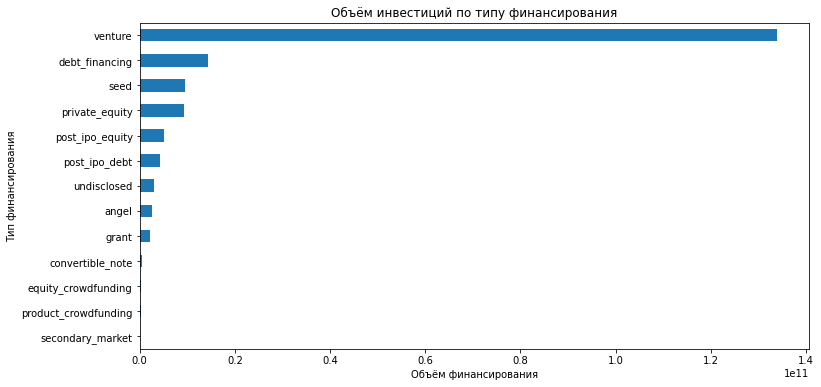

In [77]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
funding_type_df['amount'].sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Объём инвестиций по типу финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Объём финансирования')
plt.ylabel('Тип финансирования')

# Выводим график
plt.show()

По объему инвестиций венчурное финансирование (`venture`) в больше, чем 10 раз превышает ближайшего «конкурента» долговое финансирование (`debt_financing`).

Визуализируем популярность типа финансирования.

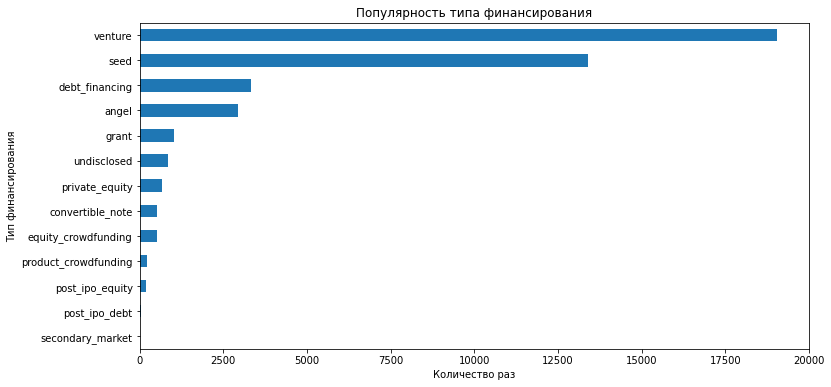

In [78]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
funding_type_df['count'].sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Популярность типа финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Количество раз')
plt.ylabel('Тип финансирования')

# Выводим график
plt.show()

Типы финансирования `venture` и `seed` самые популярны среди компаний. Они встречаются более 10000 раз каждая. Затем идут типы финансирования `debt_financing`,`angel` и `grant` на них приходится 3312, 2938 и 1020 компаний соответственно. На остальные типы финансирования приходится менее 1000 случаев. Самыми не популярными типами являются `post_ipo_debt` и `secondary_market`, на них приходится 29 и 8 компаний соответственно.

#### Промежуточные выводы:

Посевные инвестиции (`seed`) являются одними из самых популярных типов финансирования при этом их «чеки» являются одними из самых низких. Ниже чеки только у долевого краудфандинга (`equity_crowdfunding`). А вот у двух типов финансирования связанных с IPO (`post_ipo_debt` и `post_ipo_equity`) наоборот, чеки самые высокие при одних из самых низких популярностей. Менее популярен только вторичный рынок (`secondary_market`).

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [79]:
# Создаем словарь
funding_returns_dict = {'funding_types':['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'],
                'returns': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

# Создаём датафрейм из словаря
funding_type_returns_df = pd.DataFrame(funding_returns_dict)

# Заполняем словарь
for funding_type in funding_type_returns_df['funding_types'].unique():
    funding_type_returns_df.loc[funding_type_returns_df['funding_types'] == funding_type, 'returns'] = df_returns[funding_type].sum()

# Меняем индекс
funding_type_returns_df = funding_type_returns_df.set_index('funding_types')

# Выводим на экран
funding_type_returns_df.sort_values(by='returns', ascending=False)

,returns
funding_types,
venture,40578.62
debt_financing,4734.85
private_equity,3587.33
seed,2382.24
angel,1509.23
post_ipo_equity,1104.96
undisclosed,730.88
post_ipo_debt,91.03
convertible_note,34.79


Визуализируем результат для наглядности.

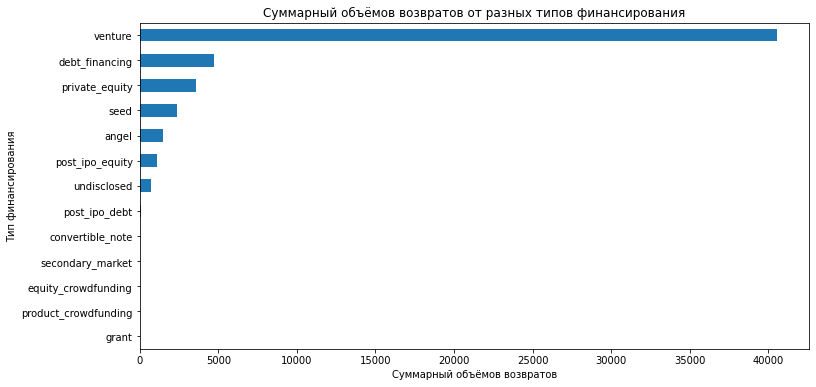

In [80]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
funding_type_returns_df['returns'].sort_values(ascending=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Суммарный объёмов возвратов от разных типов финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Суммарный объёмов возвратов')
plt.ylabel('Тип финансирования')

# Выводим график
plt.show()

Самый большой суммарный объёмов возвратов у венчурного финансирования (`venture`). Он больше чем в восемь с половиной раз превышает объем возвратов следующий тип финансирования – долговое (`debt_financing`). Самые маленькие возвраты у обоих видов краудфандинга (`equity_crowdfunding` и `product_crowdfunding`). А нулевые показатели у грантового финансирования (`grant`), что не удивительно учитывая, что они обычно безвозмездны.

<a id='chapter_four'></a>
## Анализ динамики

### Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

In [81]:
# Рассчитываем для каждой компании средний объём одного раунда финансирования
df['funding_avg'] = df['funding_total_usd'] / df['funding_rounds']

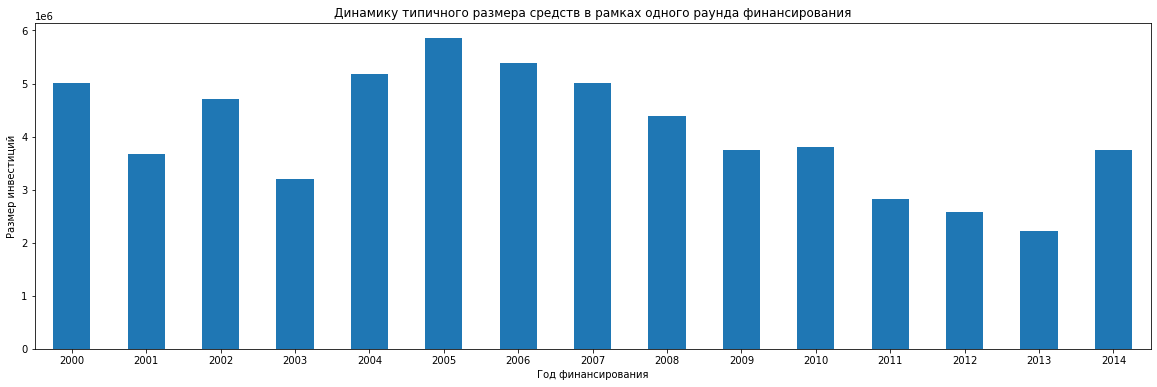

In [82]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('funding_year')['funding_avg'].mean().plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Динамику типичного размера средств в рамках одного раунда финансирования'
)

# Настраиваем оформление графика
plt.xlabel('Год финансирования')
plt.ylabel('Размер инвестиций')

# Выводим график
plt.show()

Типичный размер средств, которые стартапы получали в рамках одного раунда финансирования, колебался до 2005 года, когда был зафиксирован самый высокий показатель – более 5.8 млн. долларов США. Затем этот показатель снижался до 2013 года, когда достиг "дна" в размере 2.2 млн.долларов США. В 2014 году зафиксирован всплеск 3.7 млн.долларов США.

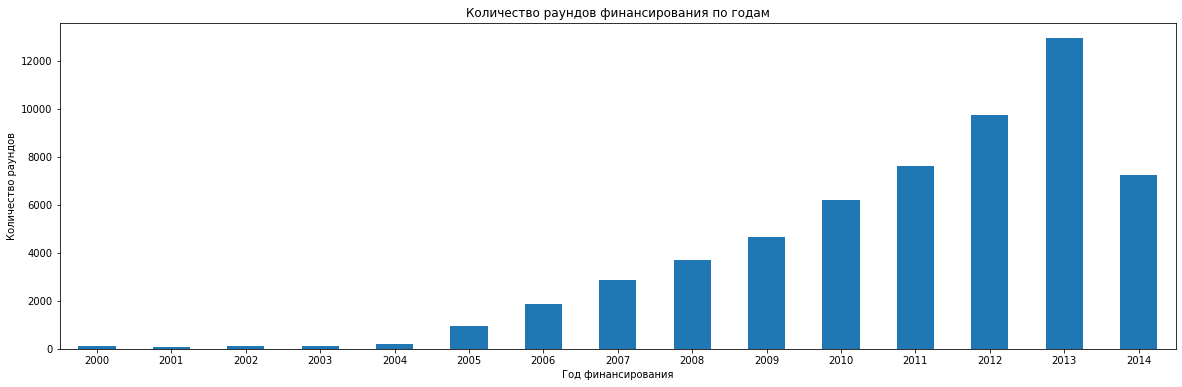

In [83]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 6))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df.groupby('funding_year')['funding_rounds'].sum().plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Количество раундов финансирования по годам'
)

# Настраиваем оформление графика
plt.xlabel('Год финансирования')
plt.ylabel('Количество раундов')

# Выводим график
plt.show()

Количество раундов финансирование стабильно росло до 2013 года. В 2014 году отмечено резкое падение активности.

#### Промежуточные выводы:

В целом, наблюдается рост количества раундов инвестиций из года в год. Не считая последний, 2014 год, когда количество раундов резко сократилось до показателей схожих с 2011 годом. Максимальный типичный размер средств, собранных в рамках одного раунда, был зафиксирован в 2005 году. Также замечено снижение типичного размера средств в рамках одного раунда финансирования до 2013 года, когда достиг "дна" в размере 2.2 млн. долларов США. В 2014 году зафиксирован всплеск 3.7 млн. долларов США.

В последнем 2014 отчетном году наблюдается снижение количества раундов по сравнению с предыдущим годом при этом типичный размер средств в рамках одного раунда финансирования выше предыдущих нескольких лет и сопоставим с показателями 2010 года.

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка.

In [84]:
# Составляем сводную таблицу
market_year_funding = df.pivot_table(index='market', columns='funding_year', values='funding_total_usd', aggfunc='sum').fillna(0).drop(['mid', 'niche'])

# Отбрасываем сегменты, которые не росли в 2014 году
market_year_funding_on_rise = market_year_funding[market_year_funding[2014] > market_year_funding[2013]]

# Выводим результат на экран
market_year_funding_on_rise

funding_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
apps,0.0,0.0,0.0,0.0,0.0,0.0,1310600.0,0.0,4300000.0,7219000.0,6123779.0,18374071.0,32601125.0,28868621.0,66237730.0
big data,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7780000.0,2452515.0,597375.0,39233297.0,60369158.0,86413341.0,78698922.0,79232600.0
design,0.0,0.0,0.0,0.0,0.0,9300000.0,707000.0,10800000.0,5944302.0,2150144.0,17239975.0,8899967.0,39630692.0,60958835.0,68988516.0
internet,10000000.0,0.0,1100000.0,0.0,10500000.0,1775000.0,5000.0,4495379.0,23412964.0,38195773.0,36657500.0,36859032.0,28288685.0,69732096.0,117830756.0
manufacturing,56659310.0,2368582.0,0.0,4269608.0,3000000.0,61770000.0,163957751.0,147726051.0,173054260.0,422862531.0,244329661.0,561639285.0,522205168.0,393936634.0,416332314.0
medical,24000000.0,0.0,0.0,0.0,0.0,11090000.0,20250000.0,2100000.0,28812744.0,11566200.0,25590338.0,28540962.0,44039600.0,64469424.0,175236064.0
real estate,2500000.0,0.0,5275000.0,6292200.0,0.0,250000.0,2080000.0,33220000.0,46613100.0,38840213.0,37344608.0,20015128.0,77320857.0,92207655.0,115567364.0
saas,0.0,0.0,2000000.0,0.0,0.0,5240000.0,4791121.0,14652595.0,27226900.0,13536585.0,32609390.0,32223749.0,49699912.0,79576613.0,92807752.0
startups,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5010387.0,460700.0,2111966.0,19654403.0,12358782.0,18080552.0,41501837.0


Визуализируем результат для наглядности.

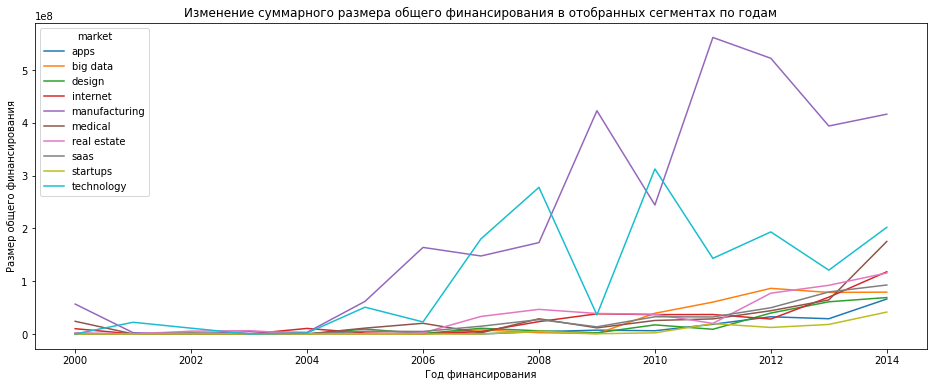

In [85]:
# Строим линейную диаграмму с помощью pandas через plot(kind='line')
market_year_funding_on_rise.T.plot(
                kind='line',
                figsize=(16, 6),
                rot=0,
                legend=True,
                title=f'Изменение суммарного размера общего финансирования в отобранных сегментах по годам'
)

# Настраиваем оформление графика
plt.xlabel('Год финансирования')
plt.ylabel('Размер общего финансирования')

# Выводим график
plt.show()

Среди «растущих» сегментов в рассматриваемый период особо сильно бросаются в глаза два сегмента, которые привлекли наибольшее количество средств в 2014 году - `manufacturing` и `technology`. Однако, для обоих этих секторов характерна высокая волатильность. Кроме этого, для сегмента `technology` пиковые показатели были достигнуты не в последнем отчетном 2014 году, а в 2010 году.

Самый уверенный рост показывают сегменты `apps` и `saas`, а в сегменте `big data` - уверенный рост, сменился плато. Для сегментов `design`, `startups` были характерны колебания, которые сменились уверенным ростом. Сегменты `internet` и `medical` показали значительный рост в последний 2014 год. В сегменте `real estate` зафиксировано ослабление, которое сменилось ростом.

#### Промежуточные выводы:

Большинство сегментов в выборке (`apps`, `saas`, `design`, `startups`, `internet`, `medical`, `real estate`) показывают относительно стабильный рост в рассматриваемый период. У одного сегмента – `big data` – уверенный рост сменился плато.Также, встречаются сегменты, такие как `manufacturing` и `technology` с высокой волатильностью. Кроме этого, для сегмента technology пиковые показатели были достигнуты не в последнем отчетном 2014 году

### Годовая динамика доли возвращённых средств по типам финансирования

Посчитаем какую долю возвращённые средства составляют от предоставленных.

In [86]:
# Создаем датафрейм, который будет хранить значения предоставленных средств для каждого года и каждого вида финансирования
investments = df.groupby('funding_year')[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']].sum()

# Создаем датафрейм, который будет хранить нормированные значения возврата средств для каждого года и каждого вида финансирования
normalized_returns = (df_returns * 1000000) / (investments + 1)

# Выводим на экран часть результата
normalized_returns

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.147591,0.000000,0.362919,0.000000,0.618571,0.266956,0.0,0.000000e+00,2.710693e-01,0.000000,0.025911,0.000000
2001,0.109095,0.082357,0.000000,0.462126,0.006667,0.770258,1.179999,0.0,0.000000e+00,4.600000e+05,0.000000,460000.000000,0.000000
2002,0.629706,0.611690,0.000000,0.608878,20000.000000,0.223388,1.136666,0.0,3.251376e-02,1.133330e+00,0.000000,60000.000000,0.000000
2003,0.505276,0.584308,0.000000,0.914397,10000.000000,1.038094,0.605720,0.0,1.620000e+06,2.110000e+06,0.000000,80000.000000,0.000000
2004,0.548475,0.768862,0.000000,0.336073,10000.000000,0.439698,0.833504,0.0,2.190000e+06,3.380000e+06,0.000000,550000.000000,0.000000
2005,0.674695,0.536192,0.000000,1.071992,20000.000000,0.344964,0.509894,0.0,4.799999e-01,7.318564e-01,0.000000,50000.000000,0.000000
2006,0.925372,0.336951,0.203631,0.650586,0.150747,0.803772,0.674853,0.0,4.653793e-01,2.058000e+07,0.000000,120000.000000,0.000000
2007,0.366153,0.295054,10000.000000,0.504971,0.228097,0.191032,0.817837,0.0,4.534642e-01,2.030000e+00,0.000000,570000.000000,0.000000
2008,0.297083,0.187573,30000.000000,0.285286,0.059788,0.927484,0.412476,0.0,6.799254e-01,2.341111e+00,0.000000,470000.000000,0.000000


In [87]:
# Заменяем неадекватные выбросы на пропуски
normalized_returns.loc[[2002, 2003, 2004, 2005], 'private_equity'] = np.nan

Нормированные значения возврата средств для каждого года и каждого вида финансирования рассчитаны, неадекватные выбросы заменены на пропуски.

Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Строим график.

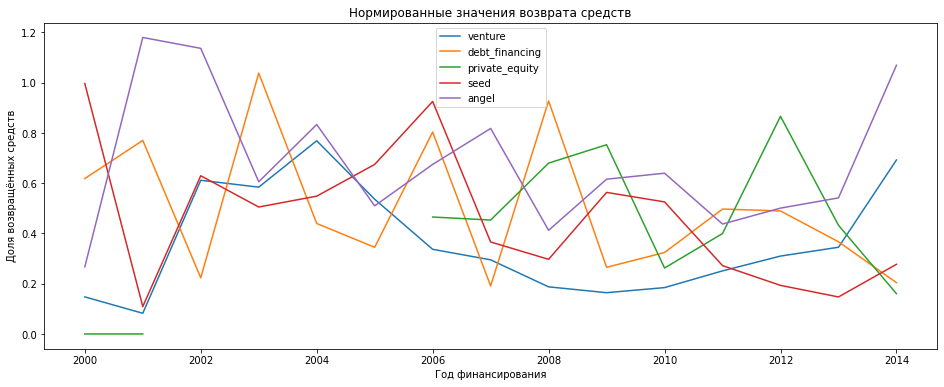

In [88]:
# Строим линейную диаграмму с помощью pandas через plot(kind='line')
normalized_returns[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']].plot(
                kind='line',
                figsize=(16, 6),
                rot=0,
                legend=True,
                title=f'Нормированные значения возврата средств'
)

# Настраиваем оформление графика
plt.xlabel('Год финансирования')
plt.ylabel('Доля возвращённых средств')

# Выводим график
plt.show()

Судя по результат анализа кратного возращения средств, не наблюдается, возможно это связано с тем, что венчурный рынок в наблюдаемый период больше вкладывает, нежели «выходит» (exit) и большие возвраты ожидаются в будущем, что в целом характерно для этого вида финансирования.
Если говорить о видах финансирования, которые нас интересуют:
- В последние годы, а точнее с 2009 года, эффективность венчурного инвестирования (`venture`) стабильно растет и приближается к пиковым значениям 2004 года.
- Долговое финансирование (`debt_financing`) показывает высокую волатильность, показатели «скачут» и года в год. Однако, с 2009 года наблюдается спад эффективности.
- Данные о нормированных значениях возврата средств для прямых (частных) инвестиций (`private_equity`) неполная, имелись аномальные значения, которые были заменены пропусками. Тем не менее, судя по имеющимся данным эффективность этого вида финансирования не столь высока – она волатильна и имеет нисходящий тренд.
- В посевных инвестициях (`seed`) наблюдается заметный спад эффективности, несмотря на промежуточный всплеск в 2006 году. Однако, имеется нотка позитива в 2014 году – наблюдается незначительный рост эффективности.
- Ангельские инвестиции (`angel`) имели нисходящий тренд эффективности с 2001 по 2011 год. Однако с 2011 года наблюдается значительный подъем показателя.

#### Промежуточные выводы:

В двух видах финансирования (`debt_financing` и `private_equity`) наблюдается тренд спада эффективности. Для одного вида финансирования (`seed`) при позитивном последнем отчетном годе (2014 год) заметен общий нисходящий тренд эффективности.

А на два оставшихся вида финансирования – ангельские (`angel`) и венчурные (`venture`) инвестиции стоит присмотрится, в них заметен рост эффективности два и более года соответственно. Ангельские инвестиции похоже справились с нисходящим трендом, а венчурные инвестиции выбрались из «долины смерти».

<a id='chapter_five'></a>
## Итоговый вывод и рекомендации

В ходе исследования проанализировали данные до 2014 года (включительно) о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

### Общий обзор проделанной работы

Во время исследования были проделаны следующие работы:
- Проведена загрузка и знакомство с данными двух датасетов датасетов `cb_investments.csv` и `cb_returns.csv`. 
- Основной датасет cb_investments.zip содержит 40 столбцов и 54294 строк. Данные содержащиеся в датасете соответствуют описанию и дают информацию финансировании стартапов. Дополнительный датасет cb_returns.csv содержит 14 столбцов и 15 строк. Данные содержащиеся в датасете соответствуют описанию и дают информацию об общем финансировании стартапов по годам.
- Проведена предобработка дынных с исправлением неверных типов данных, нормализацией текстовых данных, удалением полных дубликатов (пустых строк), заполнением стрки содержащей общий объём привлечённых инвестиций на основе суммы связанных строк, заполнением даты среднего по времени раунда финансирования.
- Проведен инжиниринг признаков с добавлением столбца хранящего группу по срокам финансирования, а также выделены средние и нишевые сегменты рынка в отдельный сегмент.
- Проведена работа с выбросами: помечены выбросы в каждом из сегментов, определены границы рассматриваемого периода. В результате, из датасета исключены компании, которые получили аномальное финансирование или финансирование в годы, когда было зафиксировано менее 50 раундов финансирования. 
- Проведен анализ типов финансирования по объёму и популярности, а также анализ динамических показателей таких как: анализ динамики предоставления финансирования по годам, размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов, годовой доли возвращённых средств по типам финансирования


### Итоговые выводы

Анализ инвестиционных данных до 2014 года показывает высокоасимметричную и нишевую структуру стартап-рынка: лишь около 30% компаний с длительным циклом финансирования (`более года`) аккумулируют 62% всех инвестиций, тогда как почти 60% компаний получают финансирование только один раз (`единичное`) и привлекают менее трети средств (30,6%). Рынок отличается высокой гранулированностью (394 сегмента) и выраженной моделью «длинного хвоста»: более 75% сегментов являются `нишевыми`, при этом только 48 сегментов являются `массовыми` и концентрируют почти 88% всех компаний. 

Инвестиционная активность устойчиво росла до пика в 2013 году, после чего в 2014 году произошло резкое снижение числа раундов на фоне роста среднего «чека» одного раунда. Венчурное финансирование (`venture`) доминирует как по объёму инвестиций, так и по возвратам, демонстрируя восстановление эффективности после 2009 года, тогда как долговое финансирование (`debt financing`) и прямые (частные) инвестиций (`private equity`) характеризуются нисходящими и волатильными трендами. Наиболее устойчивый рост показывают сегменты `SaaS` и `apps`, тогда как `manufacturing` и `technology` отличаются высокой волатильностью. 

В целом рынок находится в инвестиционной фазе с отложенными экзитами: капитала вкладывается больше, чем возвращается, что типично для венчурной экосистемы и указывает на ожидание будущих крупных возвратов.

###  Рекомендации

Опираясь на результаты анализа, рекомендую инвестировать в сегменты – `app` (приложения) и `SaaS` (Программное обеспечение как услуга), они показывают уверенный рост. Также следует присмотреться к сегментам – `design`, `startups`, `internet` и `medical`, они демонстрируют значительный рост в последние годы.

При выборе типа финансирования стоит присмотрится к ангельским (`angel`) и венчурным (`venture`) инвестициям, в них заметен рост эффективности два и более года соответственно. 

В целом, не стоит ждать быстрых возвратов вложенных средств, рынок находится в инвестиционной фазе с отложенными экзитами. Другими словами, сейчас капитала вкладывается больше, чем возвращается.